In [1]:
import numpy as np
import beyond21.global_wrapper as gw

In this tutorial we demonstrate how to run Beyond21 with the 2cDM model of [arXiv:1908.06986](https://arxiv.org/abs/1908.06986), as an example of a beyond-Standard-Model scenario implemented within the Beyond21 framework.

##  Create GlobalWrapper Objects
Create a Beyond21 object like in the $\Lambda {\rm CDM}$ tutorial using 
**`beyond21.global_wrapper.GlobalWrapper(...)`**

which now takes an additional dictionary argument

`DM_params` *(dict)*

that specifies the parameters of the 2cDM model.

---

### `DM_params` *(dict)*

The dictionary may contain the following keys:

- `mm` *(float)*  
  Mass of the **millicharged dark matter particle** in **eV**.

- `Q` *(float)*  
  Electric charge of the mDM particle in units of the **electron charge `e`**.

- `f_m` *(float)*  
  Fraction of the total dark-matter energy density that is **millicharged**.

- `mC` *(float, optional)*  
  Mass of the **CDM** particle in **eV**.  
  If not provided, **mDM–CDM interactions are assumed to be absent**.

- `alpha_c_alpha_m` *(float or `'max'`)*  
 **mDM–CDM** coupling.

  - If a numerical value is provided, that value is used directly.
  - If set to `'max'`, the interaction strength is automatically set to the
    **maximum viable value** according to **Appendix C.2.a** of [arXiv:1908.06986](https://arxiv.org/abs/1908.06986).

- `m_phi` *(float, default = 1e-6)*  
  Mass of the **mediator particle** that generates the mDM–CDM interaction, in **eV**.  
  The mediator mass should be chosen sufficiently small that the interaction is in the effective long-range regime. In this regime the momentum transfer cross section depends only **logarithmically** on the exact value of `m_phi`.
---


In [2]:
# Set cosmological and astrophysical parameters
# - - - - - - - - - - - - - - - - - - - - - - - 

cosmo_params = {
    'Om0' : 0.3111,
    'Ob0' : 0.0490,
    'H0' : 67.66,
    'sigma8' : 0.8102,
    'ns' : 0.9665,
    'Neff' : 3.046,
    'Y_He' : 0.24, 
    'hmf_kwargs' : {"mdef": "fof", "model": "sheth99"}
    }

star_formation_params = {
                'model' : 'PopII+PopIII',  
                'M_cutII' : 2.7e7,
                'eps_t' : 0.38,
                'F_starII' : 1.2,
                'Mpivot' : 1.3e13,
                'alphaII' : -0.46,
                'betaII' : 0.6,
                'F_starIII' : 5.4e-3,
                'alphaIII' : -0.62,
                'M_cutIII' : 2.5e6,
                'A_LW' : 2,
                'B_LW' : 0.6,
                'A_vrel' : 1,
                'B_vrel' : 1.8
                }

xray_params = {
    'LSFRII' : 10**(40.5),
   'LSFRIII' : 10**(40.5),
    'E_min' : 0.5,
    'E_max' : 15,
    'alpha_s' : 1,
    'alpha_h' : 2.2,
    'E_break' : 2,
    }

reion_params = {
    'F_escII' : 2.5e-2,
    'alpha_escII' : -0.83,
    'N_ionII' : 5000,   
   'F_escIII' : 3.5e-3,
   'alpha_escIII' : -0.8,
   'N_ionIII' : 44000
}

DM_params = {
    'mm' : 5e8,    
    'Q' : 2e-3,    
    'f_m' : 1e-4,  
    'mC' : 2e8,   
    'alphaI_alphaC' : 'max', 
    'm_phi' : 1e-8, 
    } 


# Initialize the global object and compute astrophysics history
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
GlobalObj = gw.GlobalWrapper(cosmo_params = cosmo_params, star_formation_params = star_formation_params, xray_params = xray_params, reion_params = reion_params, DM_params = DM_params, Lya_Heat = False, CMB_Heat = False, photoheat = True)



## Run IGM Evolution

To compute IGM properties run  **`GlobalWrapper.EvolveSM(...)`**

This function accepts up to **four optional arguments**:

- `z_min` *(float, default = 6)*  
  Minimum redshift at which the evolution ends. Very small values may cause errors for extreme models.

- `z_max` *(float, default = 1200)*  
  Redshift at which the evolution begins. Must be greater than 1200.

- `Npoints` *(int, default = 250)*  
  Number of output points, sampled uniformly in the logarithm of the scale factor:  
  `np.linspace(np.log(1 / (1 + z_max)), np.log(1 / (1 + z_min)), Npoints)`

- `ivp_kwarges` *(dict, default = {"rtol":1e-4,"max_step":0.01})*  
  kwargs for solve_ivp  


In [3]:
# Run IGM evolution from z = 1200 to z = 6
# - - - - - - - - - - - - - - - - - - - - -
GlobalObj.EvolveIGM_2cDM(z_min = 5, z_max = 1200, Nz = 250, ivp_kwargs = {"rtol":1e-4,"max_step":0.01}) # For 2cDM


<h1 style="text-align: center;"> Output Data and Plotting</h1>


After running Evolve2cDM the following quantities are avialable directly

In [4]:
rs = GlobalObj.rs            # Array of redshift values (1 + z)

# Temperatures
T21 = GlobalObj.T21          # T21 signal in Kelvin
Tbaryon = GlobalObj.Tbaryon  # baryon temperature in Kelvin
Tspin = GlobalObj.Tspin      # spin temperature in Kelvin
TCMB = GlobalObj.TCMB        # CMB temperature in Kelvin
TmDM = GlobalObj.TIDM        # mDM temperature in Kelvin
TCDM = GlobalObj.TCDM        # CDM temperature in Kelvin

# Hydrogen ionization
xHI = GlobalObj.xHI          # neutral hydrogen fraction
tau = GlobalObj.tau          # CMB optical depth to reionization

### Plot thermal evolution

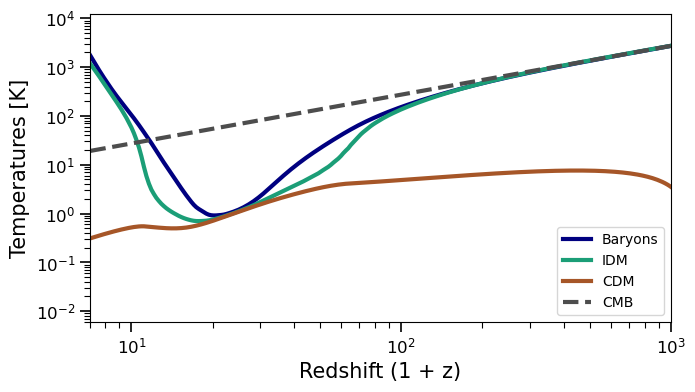

In [5]:
# Baryon Temperature Plotting function
plot_kwargs = {'label' : 'Baryons', 'color': 'navy'}
fig,ax = GlobalObj.plot_Tbaryon(**plot_kwargs)

# CMB Temperature Plotting function - Plot on the same axis
plot_kwargs = {'label' : 'IDM', 'color' : '#1B9E77'}
GlobalObj.plot_TIDM(axis = ax, **plot_kwargs)

# CMB Temperature Plotting function - Plot on the same axis
plot_kwargs = {'label' : 'CDM', 'color' : '#A65628'}
GlobalObj.plot_TCDM(axis = ax, **plot_kwargs)

# CMB Temperature Plotting function - Plot on the same axis
plot_kwargs = {'label' : 'CMB', 'color' : '#4D4D4D', 'linestyle' : 'dashed'}
GlobalObj.plot_TCMB(axis = ax, **plot_kwargs)

# Style axis
ax.set_ylabel('Temperatures [K]')
ax.set_xlim(7,1000)
ax.legend()


### Plot global 21-cm evolution

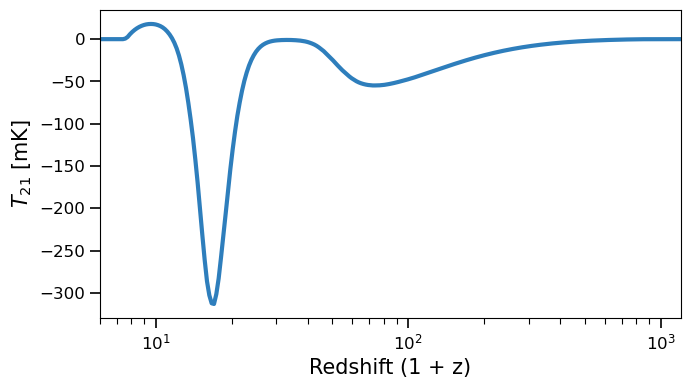

In [6]:
# (Optional) Customize plot appearance using standard matplotlib keyword arguments passed to ax.plot
plot_kwargs = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 3}

# Running plotting function
fig,ax = GlobalObj.plot_T21()

#(Optional) Further customize the axes using standard matplotlib commands
# ax.set_xlim(7,30)
# ax.set_ylim(-100,40)
# ax.set_xscale('linear')

### Plot combined evolution: baryon (Kinetic), hydrogen spin, and CMB temperatures

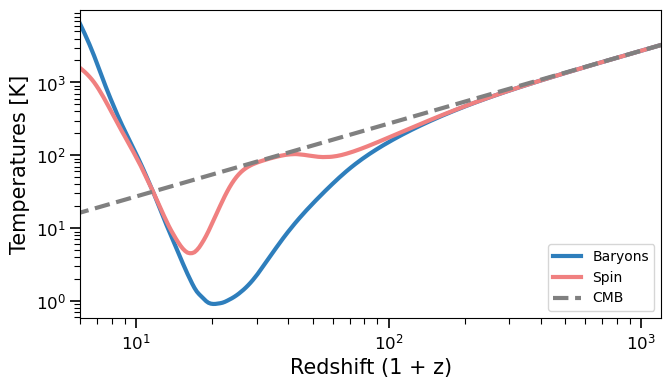

In [7]:
# Baryon Temperature Plotting function
plot_kwargs = {'label' : 'Baryons'}
fig,ax = GlobalObj.plot_Tbaryon(**plot_kwargs)

# Spin Temperature Plotting function - Plot on the same axis
plot_kwargs = {'label' : 'Spin', 'color' : 'lightcoral'}
GlobalObj.plot_Tspin(axis = ax, **plot_kwargs)


# CMB Temperature Plotting function - Plot on the same axis
plot_kwargs = {'label' : 'CMB', 'color' : 'grey', 'linestyle' : 'dashed'}
GlobalObj.plot_TCMB(axis = ax, **plot_kwargs)

# Style axis
ax.set_ylabel('Temperatures [K]')
ax.legend()

<h1 style="text-align: center;">For additional outputs and plots, simply follow the &Lambda;CDM tutorial, which applies directly here.</h1>